# WER Visualisation

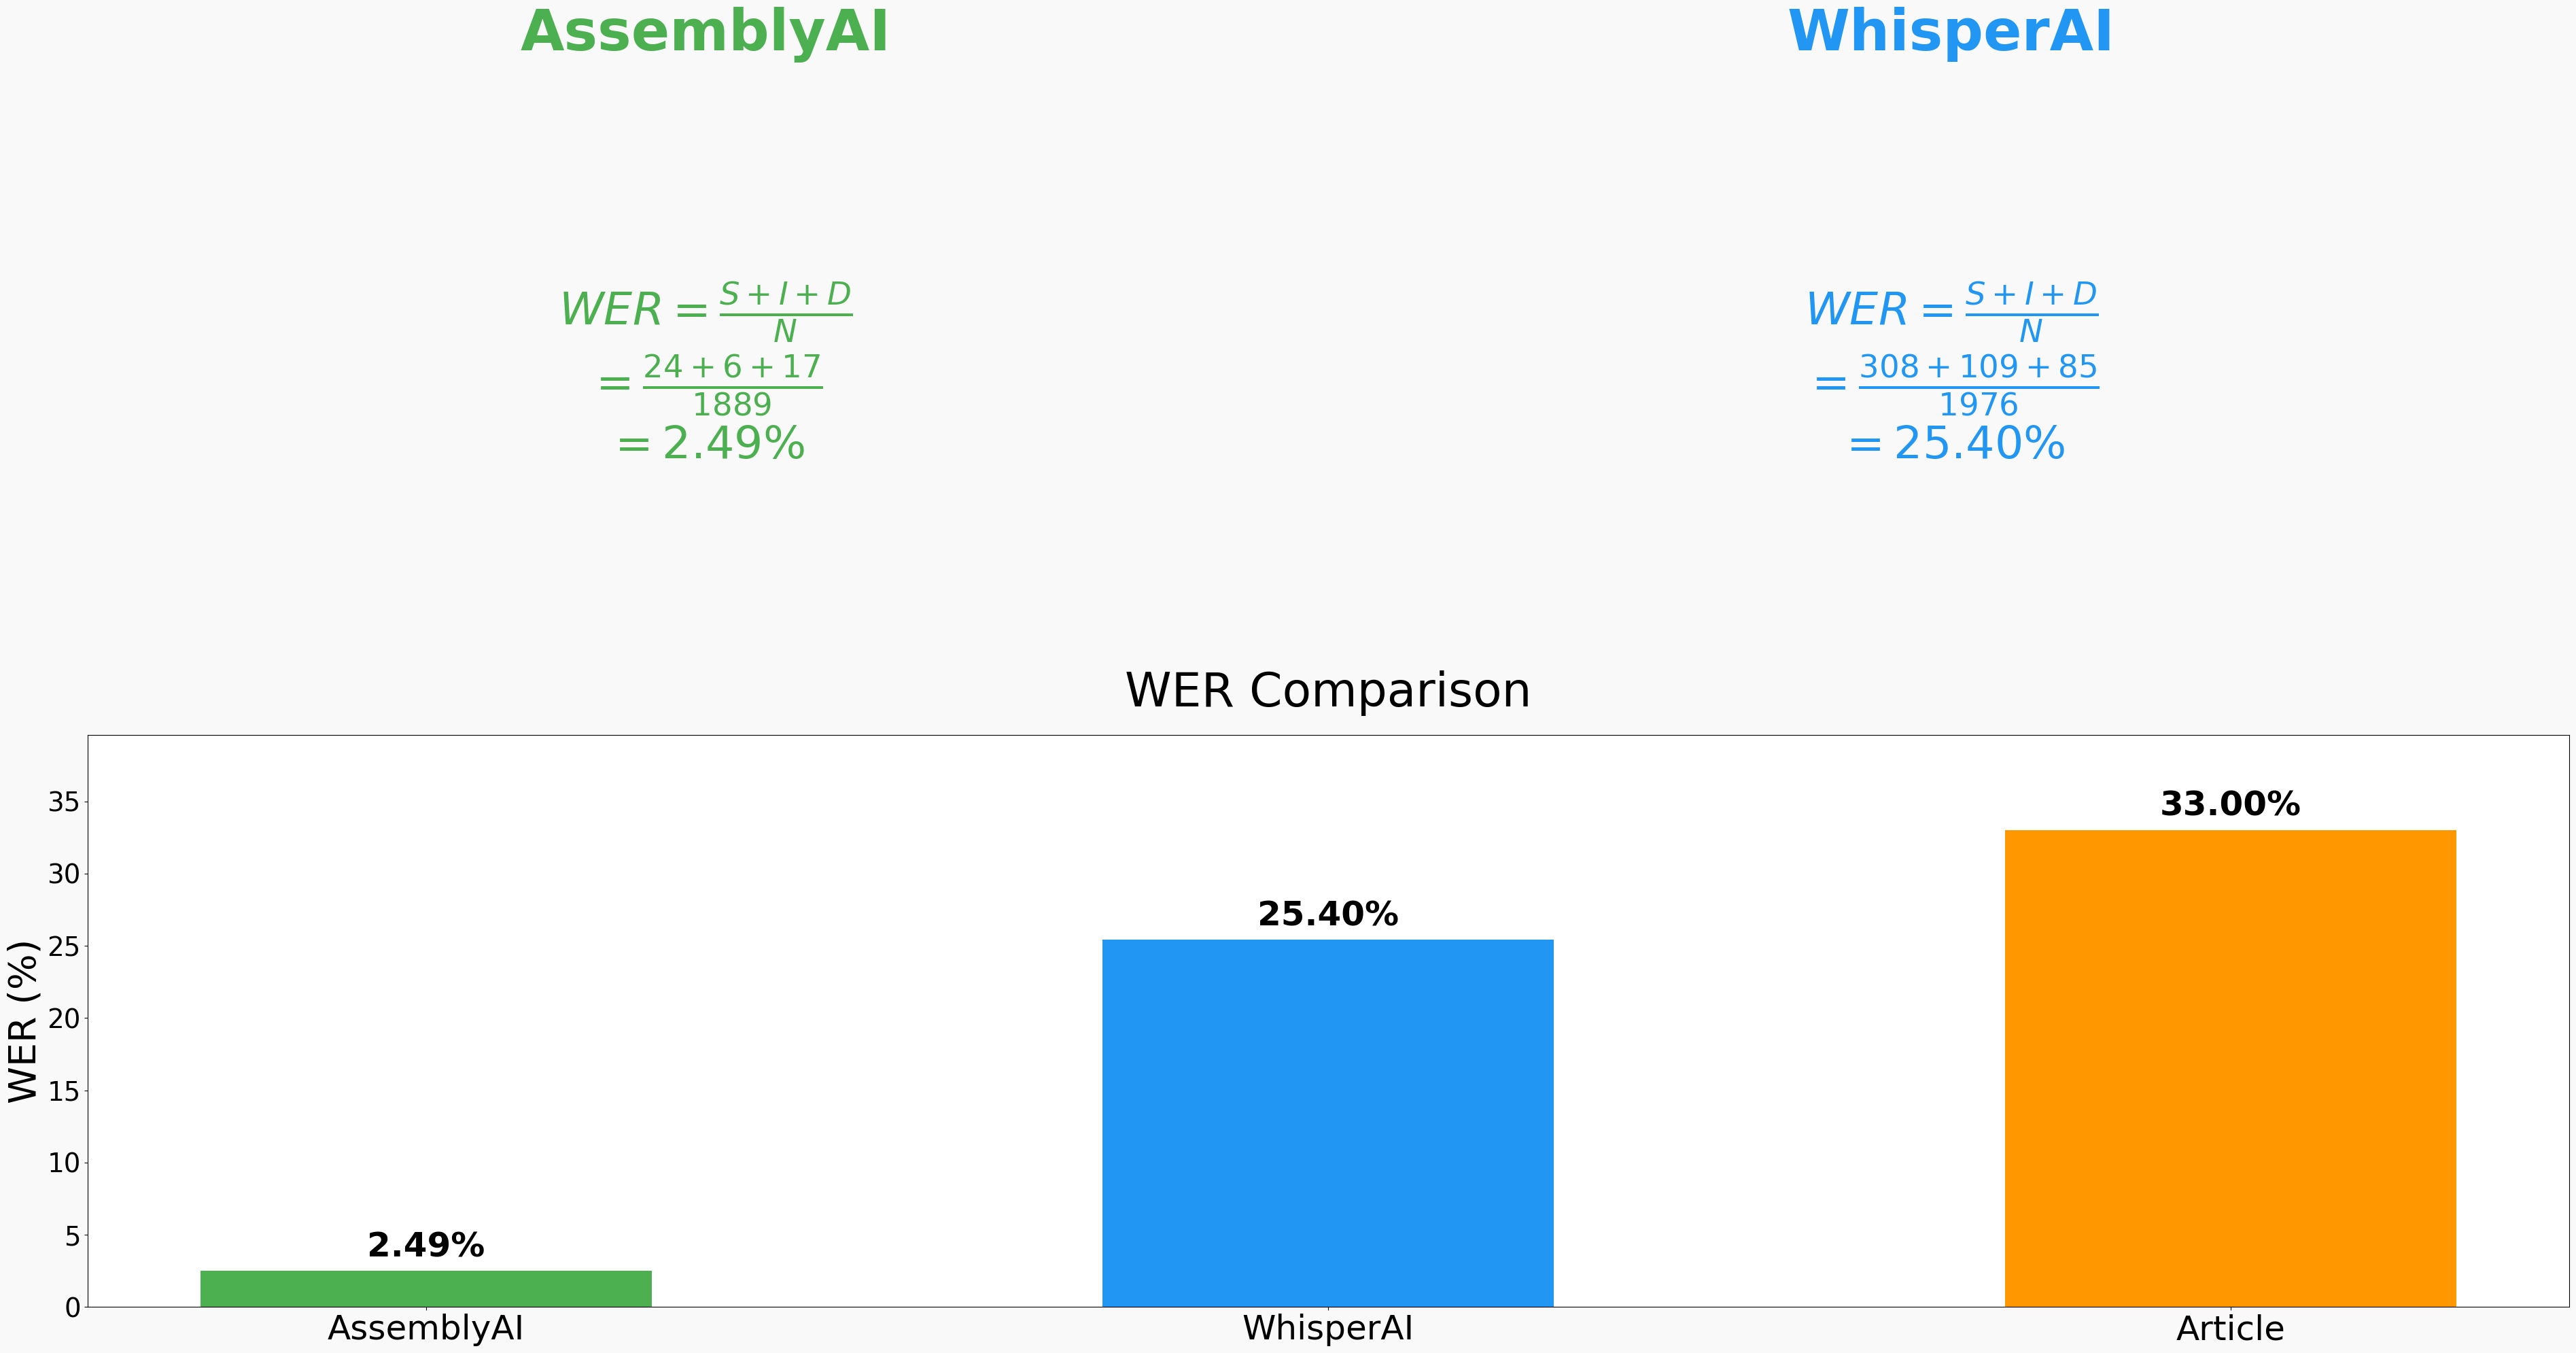

In [11]:
import matplotlib.pyplot as plt

# Data
models = ["AssemblyAI", "WhisperAI", "Article"]
colors = ["#4CAF50", "#2196F3", "#FF9800"]

# S, I, D, N values
metrics = {
    "AssemblyAI": {"S": 24, "I": 6, "D": 17, "N": 1889},
    "WhisperAI": {"S": 308, "I": 109, "D": 85, "N": 1976},
    "Article": {"S": None, "I": None, "D": None, "N": None} 
}

# Calculate WERs
WER = []
for model in models:
    data = metrics.get(model)
    if data["S"] is not None:
        wer = (data["S"] + data["I"] + data["D"]) / data["N"] * 100
    else:
        wer = 33.0  # Article WER
    WER.append(wer)

# Create figure
fig = plt.figure(figsize=(38, 20), facecolor="#f9f9f9")

# --- Top row: Formula panels ---
for i, (model, color, wer) in enumerate(zip(models[:2], colors[:2], WER[:2])):
    ax = plt.subplot(2, 2, i + 1)
    data = metrics[model]
    formula_text = (
        r"$WER = \frac{S + I + D}{N}$" + "\n" +
        f"$= \\frac{{{data['S']} + {data['I']} + {data['D']}}}{{{data['N']}}}$" + "\n" +
        f"$= {wer:.2f}\\%$"
    )
    ax.text(0.5, 0.5, formula_text,
            fontsize=48, ha="center", va="center", color=color)
    ax.set_title(model, fontsize=60, fontweight="bold", color=color, pad=40)
    ax.axis("off")
    ax.set_facecolor("white")

# --- Bottom row: Bar chart ---
ax_bar = plt.subplot(2, 1, 2)
bars = ax_bar.bar(models, WER, color=colors, width=0.5)

# Label percentages above bars
for bar, wer in zip(bars, WER):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{wer:.2f}%", ha="center", fontsize=36, fontweight="bold")

# Style bar chart
ax_bar.set_ylabel("WER (%)", fontsize=40)
ax_bar.set_title("WER Comparison", fontsize=50, pad=30)
ax_bar.tick_params(axis="x", labelsize=36)
ax_bar.tick_params(axis="y", labelsize=28)
ax_bar.set_ylim(0, max(WER) * 1.2)
ax_bar.set_facecolor("white")

plt.tight_layout()
plt.show()